# VRP con OR-Tools

En este notebook cargamos los 4 escenarios calculados en `grafo.ipynb` (las matrices de tiempo entre el depósito y las entregas, con las velocidades predichas) y los resolvemos con Google OR-Tools.

El objetivo es optimizar el makespan, es decir, el tiempo que se tarda en hacer todas las entregas. Los vehículos salen todos a la vez y en paralelo, por lo tanto, el vehículo que más tarda es lo que determina cuándo termina el reparto completo. También calculamos el tiempo total como métrica secundaria.

## 0. Importación de paquetes y carga de datos necesarios

In [1]:
!pip install ortools --quiet
!pip install osmnx --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 11.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 1.3 MB/s eta 0:00:00


In [2]:
import pickle
import pandas as pd
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

data_clean = "/content/drive/MyDrive/TFM/data_clean"

Mounted at /content/drive


In [4]:
# cargamos escenarios
with open(f"{data_clean}/escenarios_vrp.pkl", "rb") as f:
    paquete = pickle.load(f)

puntos_elegidos = paquete["puntos_elegidos"]
deposito = paquete["deposito"]
entregas = paquete["entregas"]
n_vehiculos = paquete["n_vehiculos"]
max_entregas_por_vehiculo = paquete["max_entregas_por_vehiculo"]
matrices = paquete["matrices"]

print(f"Entregas: {len(entregas)}, vehículos: {n_vehiculos}")

Entregas: 25, vehículos: 4


## 1. Función de resolución

Para resolver VRP vamos a usar OR-Tools. Es una heurística constructiva inicial (Path Cheapest Arc) combinada con una metaheurística de mejora local (Guided Local Search), que penaliza la reexploración de soluciones ya visitadas para no quedarse atascada en óptimos locales.

Le añadimos una restricción de tiempo máximo por vehículo (3 horas) y un límite de computo de 30 segundos.

Como el objetivo es optimizar el makespan, usamos `SetGlobalSpanCostCoefficient` sobre la dimensión de tiempo. Esto penaliza `max(fin de cada vehículo) - min(inicio de cada vehículo)`, que equivale al makespan ya que todos los vehículos empiezan a la vez en el mismo depósito. Vamos a calcular también el coste de arcos (`SetArcCostEvaluatorOfAllVehicles`) para usarlo como desempate entre soluciones que tengan el mismo makespan.

In [5]:
coeficiente_makespan = 100  # peso del makespan frente al coste de arcos
# resolvemos vrp con or-tools

# cuantos puntos hay, cuántos vehículos, y cuál es el índice del depósito

def resolver_vrp(matriz_tiempo, n_vehiculos, deposito_index=0, coeficiente_makespan=coeficiente_makespan):
    manager = pywrapcp.RoutingIndexManager(len(matriz_tiempo), n_vehiculos, deposito_index)
    routing = pywrapcp.RoutingModel(manager)

    def time_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return int(matriz_tiempo[from_node][to_node])

    # coste de arcos
    transit_callback_index = routing.RegisterTransitCallback(time_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    routing.AddDimension(
        transit_callback_index,
        0,
        10800,  # 3h max por vehiculo
        True,
        "Tiempo"
        )

    # makespan
    time_dimension = routing.GetDimensionOrDie("Tiempo")
    time_dimension.SetGlobalSpanCostCoefficient(coeficiente_makespan)

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    search_parameters.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    # tiempo de computo
    search_parameters.time_limit.FromSeconds(30)

    solution = routing.SolveWithParameters(search_parameters)
    return manager, routing, solution

A continuación, recorremos la solución vehículo por vehículo, siguiendo la cadena de la siguiente parada desde el depósito hasta volver a él. Vamos acumulando qué puntos visita y cuánto tiempo tarda. Vamos a descartar los vehículos a los que no se les ha asignado ninguna entrega (van de depósito a depósito) ya que puede que OR-Tools encuentre más eficiente concentrar las entregas en menos vehículos.

In [6]:
# extraemos las rutas de la solucion

def extraer_rutas(manager, routing, solution, n_vehiculos, puntos_elegidos):
    rutas = []
    tiempo_total_global = 0

    for vehiculo_id in range(n_vehiculos):
        index = routing.Start(vehiculo_id)
        ruta_puntos = []
        tiempo_ruta = 0

        while not routing.IsEnd(index):
            node = manager.IndexToNode(index)
            ruta_puntos.append(puntos_elegidos[node])
            previous_index = index
            index = solution.Value(routing.NextVar(index))
            tiempo_ruta += routing.GetArcCostForVehicle(previous_index, index, vehiculo_id)

        ruta_puntos.append(puntos_elegidos[manager.IndexToNode(index)])

        if len(ruta_puntos) > 2:  # descartamos vehiculos sin ruta
            rutas.append({
                "vehiculo": vehiculo_id,
                "puntos": ruta_puntos,
                "n_entregas": len(ruta_puntos) - 2, # quitamos deposito d einicio y final
                "tiempo_segundos": tiempo_ruta,
                "tiempo_minutos": round(tiempo_ruta / 60, 1)
            })
            tiempo_total_global += tiempo_ruta

    return rutas, tiempo_total_global

Si dos repartos alternativos dan el mismo makespan, a veces el solver se conforma con uno sin seguir buscando, aunque pudiera haber una división de rutas mejor. Es una limitación documentada de OR-Tools, por lo tanto, si algún vehículo tiene pocas entregas mientras otro va muy cargado, puede ser por esto.

## 2. Resolvemos los escenarios

In [7]:
resultados_ortools = {}

for nombre_escenario, matriz in matrices.items():
    print(f"\n{nombre_escenario}")
    print("="*30)
    manager, routing, solution = resolver_vrp(matriz, n_vehiculos, deposito_index=0)

    if not solution:
        print("No se ha encontrado solución")
        continue

    rutas, tiempo_total = extraer_rutas(manager, routing, solution, n_vehiculos, puntos_elegidos)
    makespan = max(r["tiempo_segundos"] for r in rutas)

    for r in rutas:
        print(f"  Vehículo {r['vehiculo']}: {r['n_entregas']} entregas, {r['tiempo_minutos']} min")
    print(f"  Vehículos usados: {len(rutas)} de {n_vehiculos}")
    print(f"  Makespan: {round(makespan/60, 1)} min")
    print(f"  Tiempo total: {round(tiempo_total/60, 1)} min")

    resultados_ortools[nombre_escenario] = {
        "rutas": rutas,
        "tiempo_total": tiempo_total,
        "makespan": makespan,
        "n_vehiculos_usados": len(rutas),
    }


historico_lgbm
  Vehículo 0: 4 entregas, 141.4 min
  Vehículo 1: 10 entregas, 126.7 min
  Vehículo 2: 9 entregas, 138.3 min
  Vehículo 3: 2 entregas, 141.9 min
  Vehículos usados: 4 de 4
  Makespan: 141.9 min
  Tiempo total: 548.3 min

historico_gcn
  Vehículo 0: 12 entregas, 132.0 min
  Vehículo 1: 2 entregas, 142.7 min
  Vehículo 2: 5 entregas, 142.9 min
  Vehículo 3: 6 entregas, 143.4 min
  Vehículos usados: 4 de 4
  Makespan: 143.4 min
  Tiempo total: 561.1 min

vivo_lgbm
  Vehículo 0: 5 entregas, 139.1 min
  Vehículo 1: 2 entregas, 136.2 min
  Vehículo 2: 12 entregas, 134.6 min
  Vehículo 3: 6 entregas, 138.9 min
  Vehículos usados: 4 de 4
  Makespan: 139.1 min
  Tiempo total: 548.9 min

vivo_gcn
  Vehículo 0: 9 entregas, 145.3 min
  Vehículo 1: 5 entregas, 151.3 min
  Vehículo 2: 7 entregas, 151.4 min
  Vehículo 3: 4 entregas, 151.7 min
  Vehículos usados: 4 de 4
  Makespan: 151.7 min
  Tiempo total: 599.8 min


## 3. Guardamos los resultados

Finalmente guardamos los resultados para luego cargarlos en `grafo.ipynb`, en el apartado de comparativa final.

In [8]:
with open(f"{data_clean}/resultados_ortools.pkl", "wb") as f:
    pickle.dump(resultados_ortools, f)

## 4. Visualización de las rutas

Vamos a dibujar las rutas de cada escenario sobre el mapa.

In [9]:
# grafo G con los pesos de los escenarios

G = ox.load_graphml(
    filepath=f"{data_clean}/chicago_graph_4_escenarios.graphml",
    edge_dtypes={
        "travel_time_hist_lgbm": float,
        "travel_time_hist_gcn": float,
        "travel_time_vivo_lgbm": float,
        "travel_time_vivo_gcn": float,
    }
)

nombre_peso = {
    "historico_lgbm": "travel_time_hist_lgbm",
    "historico_gcn": "travel_time_hist_gcn",
    "vivo_lgbm": "travel_time_vivo_lgbm",
    "vivo_gcn": "travel_time_vivo_gcn",
}

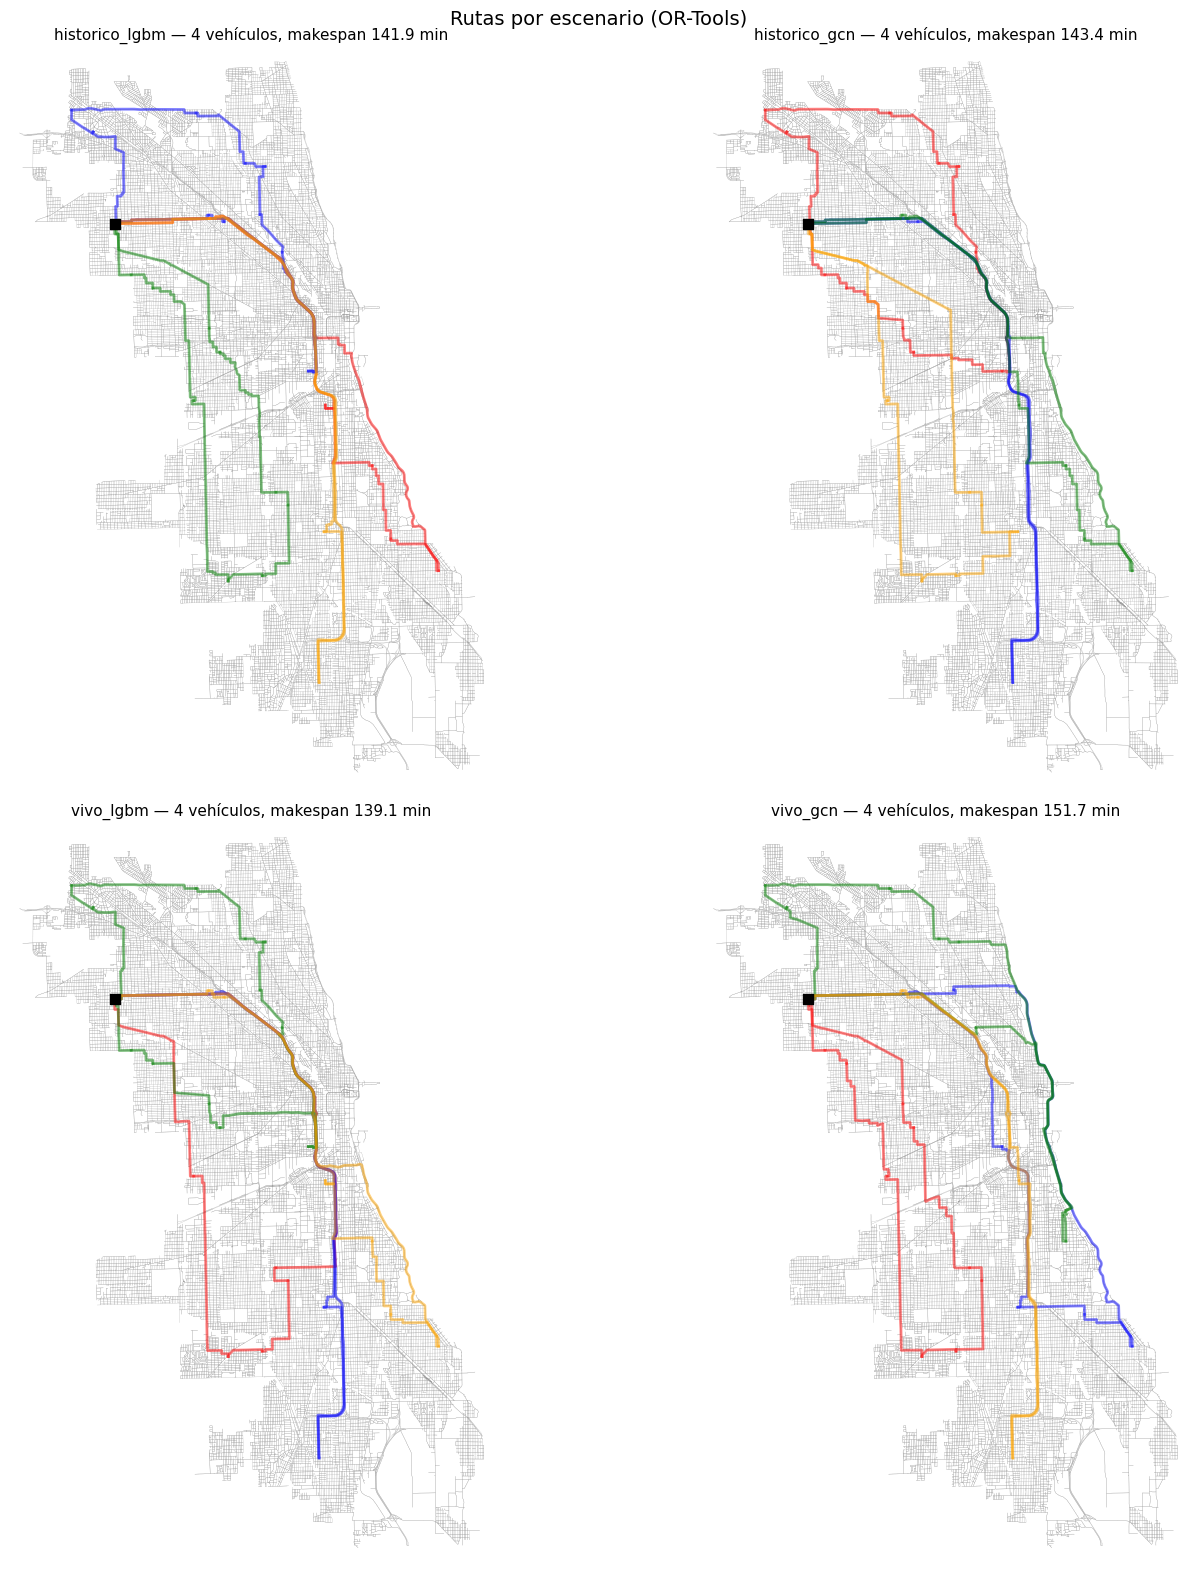

In [10]:
def dibujar_escenario(ax, G, weight_attr, rutas, deposito, entregas, titulo):
    ox.plot_graph(G, ax=ax, show=False, close=False, node_size=0, edge_linewidth=0.15, bgcolor="white")

    colores = ["red", "blue", "green", "orange", "purple", "brown", "pink", "cyan"]
    for i, r in enumerate(rutas):
        color = colores[i % len(colores)]
        for a, b in zip(r["puntos"][:-1], r["puntos"][1:]):
            camino = nx.shortest_path(G, a, b, weight=weight_attr)
            ox.plot_graph_route(G, camino, ax=ax, route_color=color, route_linewidth=2,
                                 show=False, close=False, orig_dest_size=0)

    x_dep, y_dep = G.nodes[deposito]["x"], G.nodes[deposito]["y"]
    ax.scatter(x_dep, y_dep, c="black", s=60, marker="s", zorder=5)
    ax.set_title(titulo, fontsize=11)


fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()

for ax, (nombre_escenario, weight_attr) in zip(axes, nombre_peso.items()):
    r = resultados_ortools[nombre_escenario]
    titulo = f"{nombre_escenario} — {r['n_vehiculos_usados']} vehículos, makespan {round(r['makespan']/60,1)} min"
    dibujar_escenario(ax, G, weight_attr, r["rutas"], deposito, entregas, titulo)

plt.suptitle("Rutas por escenario (OR-Tools)", fontsize=14)
plt.tight_layout()
plt.show()